# 04 — Autonomous SPM
## Machine Learning in SPM Tutorial
*RMS AFM & SPM Meeting 2026*

## Goals

By the end of this notebook you will be able to:

- Understand the **closed-loop measurement** concept in autonomous SPM
- Implement a **toy adaptive loop** that decides where to measure next
- Visualise how the **model updates** as measurements accumulate
- **Compare adaptive vs random** measurement strategies at equal budget

## What is Autonomous SPM?

Traditional SPM instruments operate on a fixed, pre-defined raster scan: the tip visits every pixel in a regular grid regardless of what is found. This is thorough but inefficient — most of the measurement budget is spent on featureless regions that add little new information.

Autonomous SPM changes this by allowing the instrument to decide **where to measure next** based on what it has learned so far. After each measurement, a lightweight model is updated and an *acquisition function* scores every candidate location. The point with the highest score — typically where the model is most uncertain or where interesting structure is predicted — is selected and measured. The loop then repeats.

A useful analogy: imagine a scientist who glances at a sample under an optical microscope before diving into a high-resolution scan. They would naturally focus attention on regions that look unusual or complex, rather than methodically scanning every square micrometre. Autonomous SPM formalises that intuition and executes it at instrument speed. Practical applications include finding rare surface defects, rapidly localising grain boundaries, and efficient multi-scale imaging where high-resolution passes are only triggered where needed.

In [ ]:
# --- Colab bootstrap: clone the repo & install deps when running on Google Colab ---
# (Does nothing when you run locally from the cloned repo.)
import os, sys
if 'google.colab' in sys.modules:
    if not os.path.exists('RMS-AFM-SPM-Meeting-2026'):
        !git clone -q https://github.com/Liambcollins/RMS-AFM-SPM-Meeting-2026.git
    %cd RMS-AFM-SPM-Meeting-2026/notebooks
    !pip -q install scikit-image >/dev/null 2>&1
    print('Colab setup complete.')

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
import numpy as np
import matplotlib.pyplot as plt
from synthetic.generators import make_adaptive_target
from ml.active_learning import (distance_uncertainty, gradient_score,
                                 acquisition_function, select_next_point,
                                 rbf_estimate)
from ml.reconstruction import reconstruction_error
from viz.plotting import set_style, plot_adaptive_state
set_style()

## The Synthetic Measurement Target

Target image: (32, 32)


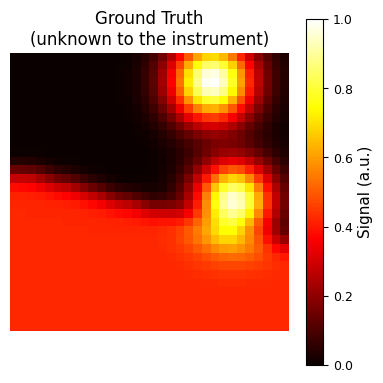

In [2]:
size = 32
target = make_adaptive_target(size=size, random_state=42)
print(f"Target image: {target.shape}")

plt.figure(figsize=(4, 4))
plt.imshow(target, cmap='hot', origin='lower')
plt.title("Ground Truth\n(unknown to the instrument)")
plt.colorbar(label='Signal (a.u.)')
plt.axis('off')
plt.tight_layout()
plt.show()

## The Adaptive Loop

The algorithm follows a simple cycle:

1. **Start** with a small number of random measurements scattered across the field of view — these *seed* measurements give the model something to work with.
2. **Fit a simple model** to the currently measured points. Here we use a radial-basis-function (RBF) interpolation, but in a real system this might be a Gaussian Process.
3. **Compute an uncertainty/acquisition map** over all unmeasured pixels. Regions that are far from any existing measurement, or where the model predicts strong gradients, score highly.
4. **Select the pixel with the highest acquisition score** as the next measurement point.
5. **Measure** that pixel (in this toy demo: look up the ground-truth value) and add it to the observed set.
6. **Repeat** from step 2.

The core idea is simple: *measure where uncertain*. Even this heuristic concentrates measurements on boundaries and features rather than flat background.

In [3]:
rng = np.random.default_rng(0)

# Start with 8 random seed measurements
n_seed = 8
seed_indices = rng.choice(size * size, n_seed, replace=False)
measured_mask = np.zeros((size, size), dtype=bool)
measured_mask_flat = measured_mask.ravel()
measured_mask_flat[seed_indices] = True
measured_mask = measured_mask_flat.reshape(size, size)

# Helper: get observed values
def get_observations(mask, target=target):
    return target[mask]

obs_values = get_observations(measured_mask)
print(f"Starting with {measured_mask.sum()} seed measurements")

Starting with 8 seed measurements


In [4]:
N_steps = 40
save_steps = [0, 5, 10, 20, 40]
history = {}  # step -> (mask copy, model_mean copy, uncertainty copy, next_pt)

for step in range(N_steps + 1):
    obs = get_observations(measured_mask)
    
    # Build model estimate
    if measured_mask.sum() < 4:
        model_mean = np.zeros((size, size), dtype=np.float32)
    else:
        model_mean = rbf_estimate(measured_mask, obs, (size, size), smoothing=0.5)
    
    # Compute uncertainty and gradient
    unc = distance_uncertainty(measured_mask, (size, size), decay=4.0)
    grad = gradient_score(model_mean)
    acq = acquisition_function(unc, gradient=grad, alpha=0.6)
    
    # Select next point
    next_pt = select_next_point(acq, measured_mask, n_candidates=3, random_state=step)
    
    if step in save_steps:
        history[step] = (measured_mask.copy(), model_mean.copy(),
                         unc.copy(), next_pt)
    
    if step < N_steps:
        # "Measure" the selected point
        measured_mask[next_pt[0], next_pt[1]] = True

print(f"Adaptive loop complete. Total measurements: {measured_mask.sum()}")

Adaptive loop complete. Total measurements: 48


## Visualising the Adaptive Loop

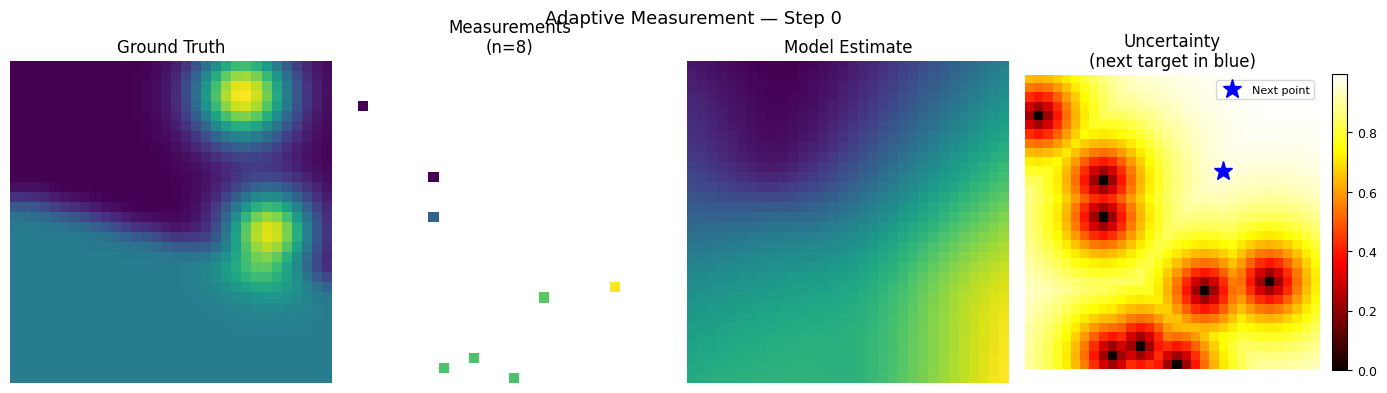

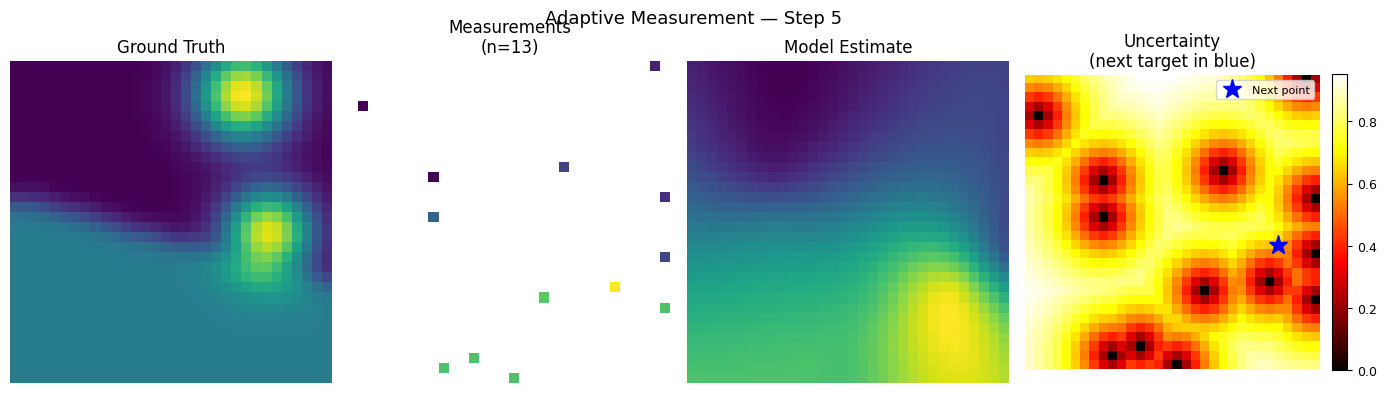

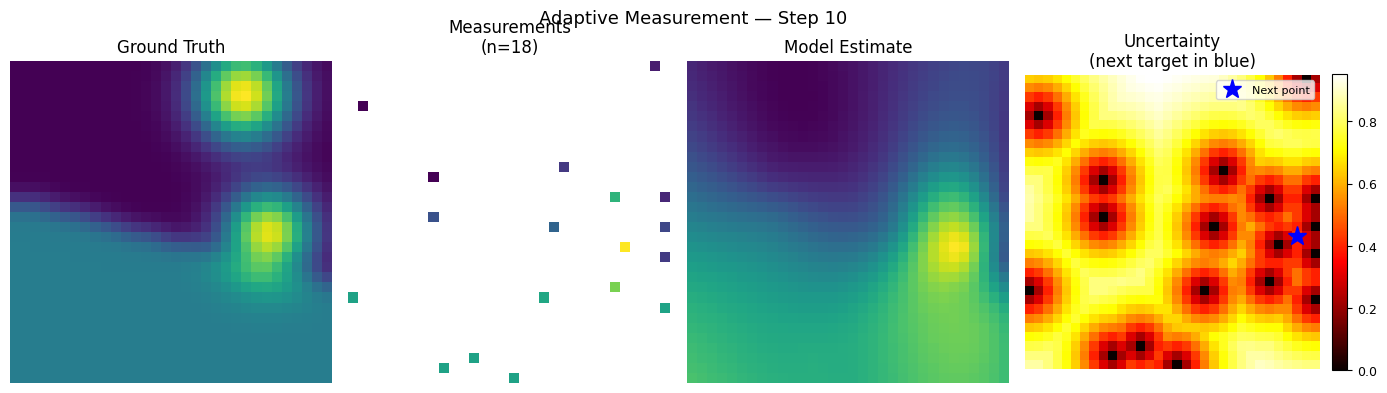

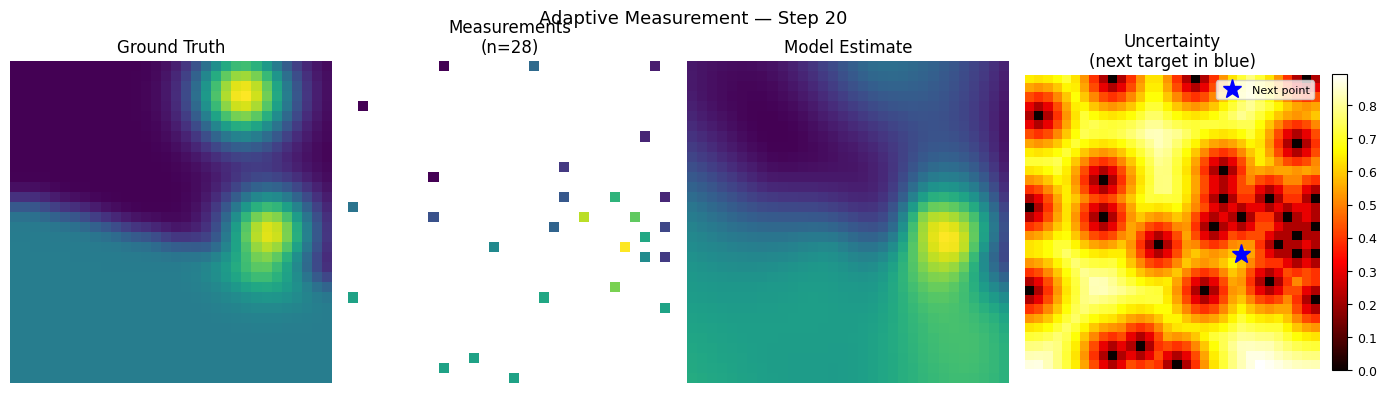

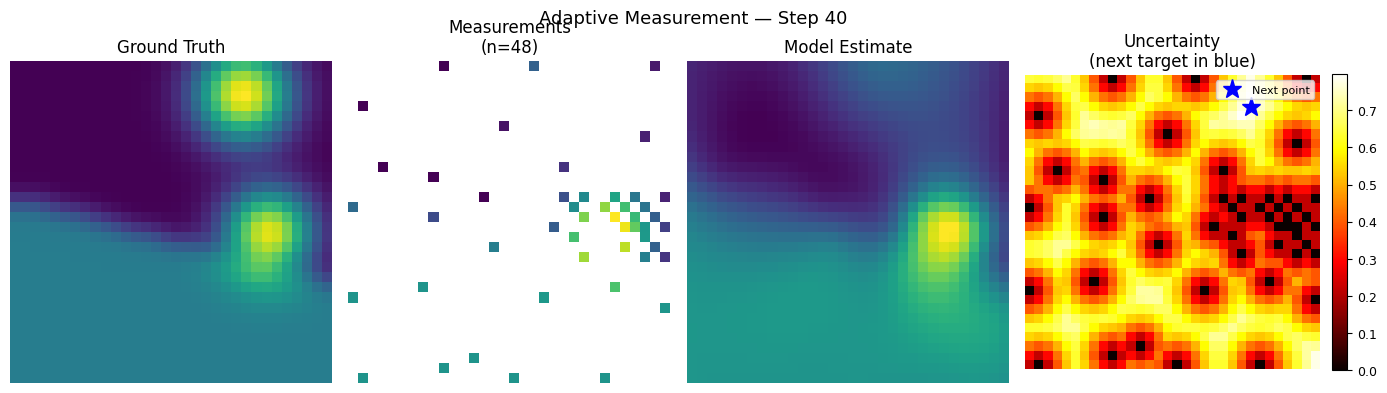

In [5]:
for step in save_steps:
    mask_s, mean_s, unc_s, next_s = history[step]
    fig = plot_adaptive_state(
        target=target,
        sampled_mask=mask_s,
        model_mean=mean_s,
        uncertainty=unc_s,
        next_point=next_s,
        step=step,
        figsize=(14, 4)
    )
    plt.show()

## Adaptive vs Random: Final Comparison

In [6]:
from ml.reconstruction import random_mask, reconstruct_griddata

n_measured = measured_mask.sum()
fraction_used = n_measured / (size * size)
print(f"Adaptive used {n_measured} measurements ({fraction_used*100:.1f}%)")

# Final adaptive reconstruction
obs_final = get_observations(measured_mask)
adaptive_recon = rbf_estimate(measured_mask, obs_final, (size, size), smoothing=0.5)
_, rmse_adaptive = reconstruction_error(target, adaptive_recon)

# Equivalent random sampling
rand_mask = random_mask(target.shape, fraction=fraction_used, random_state=99)
rand_recon = reconstruct_griddata(target, rand_mask, method='cubic')
_, rmse_random = reconstruction_error(target, rand_recon)

print(f"Adaptive RMSE: {rmse_adaptive:.4f}")
print(f"Random   RMSE: {rmse_random:.4f}")

Adaptive used 48 measurements (4.7%)
Adaptive RMSE: 0.1340
Random   RMSE: 0.0665


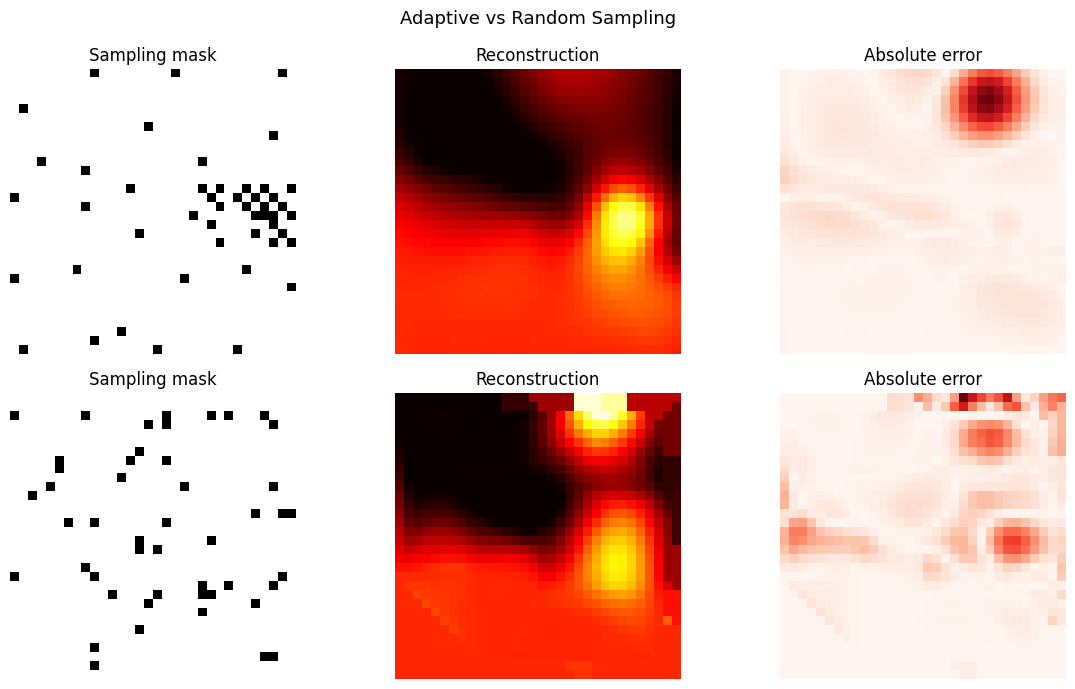

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for row_idx, (mask, recon, label) in enumerate([
    (measured_mask, adaptive_recon, f'Adaptive ({n_measured} pts, RMSE={rmse_adaptive:.4f})'),
    (rand_mask, rand_recon, f'Random ({rand_mask.sum()} pts, RMSE={rmse_random:.4f})')
]):
    # Mask / sampling pattern
    samp_img = np.zeros_like(target)
    samp_img[mask] = target[mask]
    axes[row_idx, 0].imshow(mask, cmap='Greys', origin='lower')
    axes[row_idx, 0].set_title('Sampling mask')
    
    axes[row_idx, 1].imshow(recon, cmap='hot', origin='lower',
                             vmin=target.min(), vmax=target.max())
    axes[row_idx, 1].set_title(f'Reconstruction')
    
    err = np.abs(recon - target)
    axes[row_idx, 2].imshow(err, cmap='Reds', origin='lower')
    axes[row_idx, 2].set_title('Absolute error')
    
    axes[row_idx, 0].set_ylabel(label.split('(')[0].strip(), fontsize=10)

for ax in axes.ravel():
    ax.axis('off')

fig.suptitle('Adaptive vs Random Sampling', fontsize=13)
fig.tight_layout()
plt.show()

## Measurement Path: Where Did the Instrument Look?

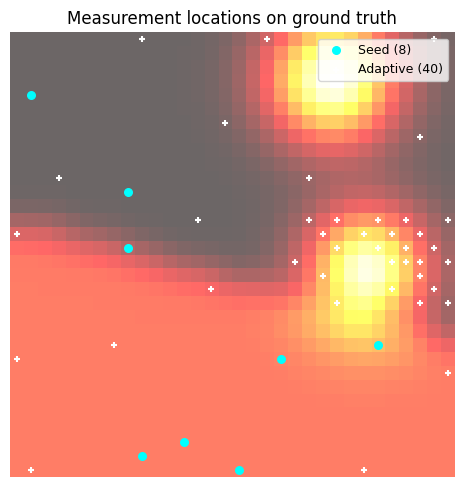

In [8]:
# Replay the loop to record measurement order (excluding seeds)
# We'll record which pixel was selected at each step

# For demo: show seeds vs adaptive measurements on target
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(target, cmap='hot', origin='lower', alpha=0.6)

# Seed points (known from seed_indices)
seed_yx = np.array(np.unravel_index(seed_indices, (size, size))).T
ax.scatter(seed_yx[:,1], seed_yx[:,0], c='cyan', s=30, marker='o',
           label=f'Seed ({n_seed})', zorder=3)

# Adaptive points (all measured minus seeds)
adaptive_only = measured_mask.copy()
adaptive_only_flat = adaptive_only.ravel()
adaptive_only_flat[seed_indices] = False
adaptive_only = adaptive_only_flat.reshape(size, size)
adap_yx = np.argwhere(adaptive_only)
ax.scatter(adap_yx[:,1], adap_yx[:,0], c='white', s=15, marker='+',
           label=f'Adaptive ({adaptive_only.sum()})', zorder=3)

ax.set_title('Measurement locations on ground truth')
ax.legend(fontsize=9, loc='upper right')
ax.axis('off')
plt.tight_layout()
plt.show()

## Takeaways

- **Autonomous SPM focuses measurement effort where it matters most** — boundaries, defects, and regions of rapid variation receive more samples than featureless background.
- **Even a simple distance-uncertainty model outperforms random** for structured fields; the benefit grows as the measurement budget shrinks.
- **The key ingredient is a fast model update + acquisition function** — the loop only adds value if both can run between consecutive measurements without becoming the bottleneck.
- **Real implementations use Gaussian Processes or neural networks** for richer uncertainty estimates, calibrated confidence intervals, and the ability to handle noise explicitly.
- **This toy demo uses only scipy and numpy** — a real system connects the acquisition function to instrument control software (e.g. Nanonis, MFP-3D controllers) so that the *next point* becomes an actual tip movement command.